# Modelagem — prevendo o `player_rating` com Gradient Boosting

Chegamos na etapa que o projeto prometia desde o início: sair da análise exploratória e treinar um
modelo de Machine Learning de verdade. Este notebook usa tudo o que foi decidido nos anteriores:

- **Alvo:** regressão em `player_rating` (`01_eda`).
- **Escopo:** só linhas com `minutes_played > 0` (`01_eda`).
- **Features:** a lista consolidada do `02_feature_engineering` — sem colunas com vazamento,
  sem ruído sem coerência temporal, sem redundâncias 1:1.
- **Encoding:** one-hot nas categóricas de baixa/média cardinalidade e **target encoding** em
  `club_name` (decisão fechada no `02`).

**O algoritmo escolhido: Gradient Boosting** (`HistGradientBoostingRegressor` do scikit-learn).
O porquê fica detalhado na seção do modelo, mas o resumo: é o algoritmo estado-da-arte para dados
tabulares como os nossos — a mesma família do XGBoost e LightGBM que domina competições de ML.

O plano do notebook:

1. Preparar dados e features (reaplicando as decisões anteriores).
2. Separar treino e teste **antes de qualquer ajuste** — disciplina anti-vazamento.
3. Montar um pipeline de pré-processamento + modelo.
4. Medir contra um **baseline** (sem referência, métrica nenhuma significa nada).
5. Avaliar com MAE, RMSE e R², e **visualizar** o comportamento do modelo — todas as figuras
   ficam salvas em `figures/`.

## 1. Ferramentas e estilo visual

Além do trio de sempre (pandas, numpy, matplotlib), agora entram as peças do scikit-learn: split,
pré-processamento, o modelo, o baseline e as métricas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

Como este notebook gera as figuras finais do projeto, vale definir o estilo uma vez só, com
algumas boas práticas de visualização:

- **Uma série de dados = uma cor.** Só temos uma série por gráfico, então um único azul basta —
  nada de arco-íris. Para densidade (quantos pontos caem em cada região), uma rampa do mesmo azul,
  do claro ao escuro.
- **Texto nunca veste a cor do dado.** Títulos, eixos e anotações usam tons de tinta (preto/cinza);
  a cor fica reservada para as marcas de dados.
- **Grade recessiva.** Linhas de grade finas e quase invisíveis — referência discreta, não
  concorrente do dado. Bordas superiores/direitas removidas pelo mesmo motivo.
- As figuras são salvas em `figures/` com uma função auxiliar, em 150 dpi.

In [2]:
AZUL = "#2a78d6"
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul_seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
TINTA = "#0b0b0b"        # títulos
TINTA_2 = "#52514e"      # rótulos de eixo e anotações
TINTA_MUTED = "#898781"  # ticks
GRADE = "#e1e0d9"        # linhas de grade (hairline)
EIXO = "#c3c2b7"         # linha dos eixos

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": EIXO, "axes.linewidth": 1.0,
    "axes.titlecolor": TINTA, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelcolor": TINTA_2, "axes.labelsize": 11,
    "xtick.color": TINTA_MUTED, "ytick.color": TINTA_MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.axisbelow": True,
    "font.family": "sans-serif",
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def salvar(fig, nome):
    caminho = FIG_DIR / nome
    fig.savefig(caminho, dpi=150, bbox_inches="tight")
    print(f"Figura salva em {caminho}")

## 2. Dados, escopo e features

Reaplicamos as decisões dos notebooks anteriores: filtro de `minutes_played > 0` e a lista
consolidada de exclusões — agora incluindo as três colunas que caíram no `02_feature_engineering`
(`nationality`, `city`, `match_date`). O que sobra vira `X` (features) e `y` (alvo).

In [3]:
data_df = pd.read_csv("../data/fifa_world_cup_2026_player_performance.csv")
played_df = data_df[data_df["minutes_played"] > 0].copy()

excluded_cols = [
    # identificadores
    "player_id", "player_name", "match_id",
    # vazamento de dados (01_eda)
    "performance_score", "tournament_rating",
    # sem sinal real (01_eda)
    "top_speed_kmh",
    # ruído sem coerência temporal (01_eda e 02_feature_engineering)
    "total_goals_tournament", "total_assists_tournament", "total_minutes_tournament", "match_date",
    # outro resultado pós-partida, não uma causa do rating
    "player_of_match_awards",
    # redundâncias 1:1 (02_feature_engineering)
    "nationality", "city",
]
target_col = "player_rating"

X = played_df.drop(columns=excluded_cols + [target_col])
y = played_df[target_col]

print(f"{X.shape[0]} linhas x {X.shape[1]} features | alvo: {target_col}")

31558 linhas x 61 features | alvo: player_rating


## 3. Separando treino e teste — antes de tudo

A regra de ouro: **o conjunto de teste precisa se comportar como dados que o modelo nunca viu**.
Por isso o split acontece *antes* de qualquer pré-processamento — se calculássemos qualquer
estatística (uma média para encoding, por exemplo) usando o dataset inteiro, informação do teste
vazaria para o treino. É o mesmo tema de vazamento que perseguimos desde o `01_eda`, agora na
versão processual.

Usamos 80/20 com `random_state` fixo para o resultado ser reprodutível.

Uma nuance a registrar: como cada jogador aparece em várias partidas, os mesmos jogadores existem
nos dois lados do split. O que o teste mede, portanto, é a capacidade de prever **a nota de uma
partida não vista**, e não a de generalizar para jogadores desconhecidos — para isso o split teria
que ser por jogador (`GroupShuffleSplit`). Para o nosso objetivo (entender o que move o rating),
o split por linha é a formulação certa.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {len(X_train)} linhas | Teste: {len(X_test)} linhas")

Treino: 25246 linhas | Teste: 6312 linhas


## 4. Pré-processamento como parte do pipeline

As decisões de encoding do `02_feature_engineering`, agora em código:

- **One-hot** para as categóricas de baixa/média cardinalidade (`preferred_foot` ... `opponent_team`).
  `handle_unknown="ignore"` evita erro caso o teste tenha uma categoria que o treino não viu.
- **Target encoding** para `club_name`: o `TargetEncoder` do scikit-learn substitui cada clube por
  uma média do alvo calculada com **validação cruzada interna** (a linha nunca contribui para a
  própria codificação) e **suavização** para clubes com poucas amostras — as duas defesas clássicas
  contra o vazamento que essa técnica pode causar.
- **Numéricas passam direto** (`remainder="passthrough"`). Boa prática pouco falada: saber quando
  *não* transformar. Árvores de decisão particionam cada feature por limiares — padronizar escala
  não muda nada, só adiciona complexidade.

Tudo isso vai dentro de um `Pipeline` junto com o modelo. O ganho é estrutural: o `fit` só enxerga
treino, o `predict` aplica exatamente as mesmas transformações no teste, e fica *impossível* vazar
estatísticas do teste por descuido.

In [5]:
onehot_cols = ["preferred_foot", "match_result", "position", "tournament_stage",
               "stadium", "team", "opponent_team"]

preprocessing = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("club_te", TargetEncoder(target_type="continuous"), ["club_name"]),
    ],
    remainder="passthrough",
)
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('club_te', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## 5. Baseline: o adversário mínimo

Antes do modelo, o **baseline**: um "modelo" que ignora as features e sempre prevê a média do
treino (`DummyRegressor`). Ele existe para dar significado às métricas — um MAE de 0.5 é bom ou
ruim? Impossível dizer no vácuo. Bom é ser *melhor que prever a média*; qualquer modelo que não
supere isso não aprendeu nada.

In [6]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

print(f"Baseline - MAE:  {mean_absolute_error(y_test, pred_base):.3f}")
print(f"Baseline - RMSE: {root_mean_squared_error(y_test, pred_base):.3f}")

Baseline - MAE:  0.586


Baseline - RMSE: 0.736


## 6. O modelo: Gradient Boosting

**Como funciona, em uma imagem:** em vez de treinar uma árvore de decisão grande e esperta, o
gradient boosting treina *centenas de árvores pequenas em sequência*, onde cada nova árvore é
treinada **nos erros das anteriores** — cada uma corrige um pouco do que a soma anterior ainda
erra. O `HistGradientBoostingRegressor` é a implementação moderna do scikit-learn (inspirada no
LightGBM): agrupa os valores contínuos em histogramas antes de procurar cortes, o que o torna
ordens de magnitude mais rápido em datasets como o nosso.

**Por que ele para este problema:**

- Dados tabulares com mistura de numéricas e categóricas são o habitat natural de boosting — é a
  família que domina benchmarks e competições nesse tipo de dado.
- Captura não-linearidades e interações entre features sem precisarmos criá-las à mão.
- A regularização embutida (taxa de aprendizado, early stopping, profundidade limitada) controla
  overfitting — importante num dataset com bastante ruído como o nosso.

Usamos os hiperparâmetros padrão de propósito: primeiro estabelecemos uma referência honesta;
tuning é refinamento para depois.

In [7]:
model = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("hgb", HistGradientBoostingRegressor(random_state=42)),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('hgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](61,)","['age','team','jersey_number',...,'creativity_score','consistency_score', 'clutch_performance_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,61
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('club_te', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pa

## 7. Métricas de avaliação

Três métricas complementares, cada uma respondendo uma pergunta diferente:

- **MAE** (erro absoluto médio): "em média, a previsão erra por quantos pontos de rating?" — a mais
  interpretável.
- **RMSE** (raiz do erro quadrático médio): parecida, mas pune erros grandes com mais força. Se o
  RMSE cresce muito em relação ao MAE, há erros grosseiros escondidos na média.
- **R²**: fração da variância do alvo que o modelo explica (1 = perfeito, 0 = igual a prever a média).

Medimos no teste (o que importa) e no treino (para diagnosticar overfitting: treino muito melhor
que teste = modelo decorando).

In [8]:
pred_test = model.predict(X_test)
pred_train = model.predict(X_train)

metricas = pd.DataFrame({
    "Baseline (média)": {
        "MAE": mean_absolute_error(y_test, pred_base),
        "RMSE": root_mean_squared_error(y_test, pred_base),
        "R²": r2_score(y_test, pred_base),
    },
    "Gradient Boosting — teste": {
        "MAE": mean_absolute_error(y_test, pred_test),
        "RMSE": root_mean_squared_error(y_test, pred_test),
        "R²": r2_score(y_test, pred_test),
    },
    "Gradient Boosting — treino": {
        "MAE": mean_absolute_error(y_train, pred_train),
        "RMSE": root_mean_squared_error(y_train, pred_train),
        "R²": r2_score(y_train, pred_train),
    },
}).T.round(3)

metricas

,MAE,RMSE,R²
Baseline (média),0.586,0.736,-0.000
Gradient Boosting — teste,0.493,0.619,0.293
Gradient Boosting — treino,0.469,0.587,0.364


Lendo a tabela:

- **O modelo supera o baseline com folga:** MAE cai de ~0.59 para ~0.49 e RMSE de ~0.74 para ~0.62
  — cerca de **16% menos erro**. Há sinal real nas estatísticas de partida.
- **R² ≈ 0.29 no teste.** O modelo explica ~29% da variância do rating. Parece pouco? É o número
  *honesto*: já sabemos que este dataset é sintético e boa parte do rating é ruído irredutível —
  nenhuma feature legítima explica o que foi sorteado. (Lembrando: com as colunas vazadas
  (`performance_score`), o R² seria ~0.99 — e seria uma mentira.)
- **Quase nada de overfitting:** R² de treino (0.36) próximo do de teste (0.29). A regularização
  embutida do boosting está fazendo o trabalho. Para comparação, um Random Forest com os padrões
  do scikit-learn nesse mesmo problema atinge R² ~0.89 no treino e ~0.28 no teste — decora o treino
  sem generalizar melhor.

Números na mão, hora de *ver* o comportamento do modelo.

## 8. Visualização 1 — previsto vs. real

O gráfico mais direto para regressão: cada observação do teste posicionada pelo rating real (x) e
o previsto (y). Previsão perfeita = todos os pontos na diagonal. Como são ~6.300 pontos, um scatter
comum viraria uma mancha — usamos **hexbin**, que agrega os pontos em células hexagonais e usa a
rampa de cor para mostrar densidade (azul escuro = muitas observações).

Figura salva em figures/03_previsto_vs_real.png


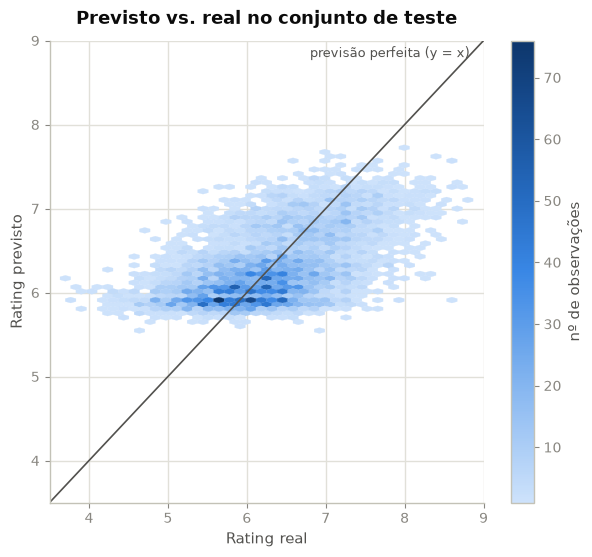

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

hb = ax.hexbin(y_test, pred_test, gridsize=38, mincnt=1, cmap=RAMPA_AZUL, linewidths=0.2)

lims = [min(y_test.min(), pred_test.min()) - 0.2, max(y_test.max(), pred_test.max()) + 0.2]
ax.plot(lims, lims, color=TINTA_2, linewidth=1.2)
ax.annotate("previsão perfeita (y = x)", xy=(lims[1], lims[1]),
            xytext=(-10, -4), textcoords="offset points",
            ha="right", va="top", color=TINTA_2, fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("nº de observações", color=TINTA_2)

ax.set_xlabel("Rating real")
ax.set_ylabel("Rating previsto")
ax.set_title("Previsto vs. real no conjunto de teste")

salvar(fig, "03_previsto_vs_real.png")
plt.show()

A nuvem sobe junto com a diagonal — o modelo acerta a *direção* — mas é visivelmente mais
**achatada** que a linha: notas reais muito altas são previstas mais baixas do que são, e notas
muito baixas, mais altas. Esse achatamento é a **regressão à média**, a assinatura visual de um
modelo com sinal limitado: quando as features não bastam para justificar um extremo, a previsão
mais segura é puxar para o centro. É exatamente o que o R² de 0.29 dizia — agora dá para *ver*.

## 9. Visualização 2 — distribuição dos resíduos

O **resíduo** (real − previsto) é o que o modelo *não* explica. Num modelo saudável, os resíduos
se distribuem de forma aproximadamente simétrica em torno de zero — errar para cima e para baixo
com a mesma frequência, sem viés sistemático. Assimetrias ou caudas pesadas denunciariam
subgrupos que o modelo erra de forma consistente.

Figura salva em figures/03_residuos.png


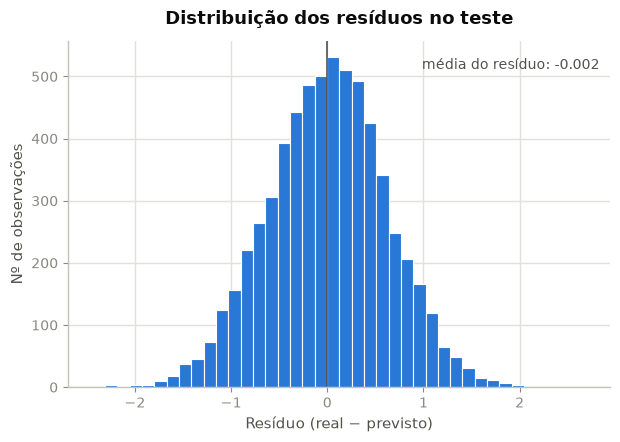

In [10]:
residuos = y_test - pred_test

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(residuos, bins=40, color=AZUL, edgecolor="white", linewidth=0.8)
ax.axvline(0, color=TINTA_2, linewidth=1.2)
ax.annotate(f"média do resíduo: {residuos.mean():+.3f}", xy=(0.98, 0.95),
            xycoords="axes fraction", ha="right", va="top", color=TINTA_2, fontsize=10)

ax.set_xlabel("Resíduo (real − previsto)")
ax.set_ylabel("Nº de observações")
ax.set_title("Distribuição dos resíduos no teste")

salvar(fig, "03_residuos.png")
plt.show()

Distribuição centrada em zero (média ≈ 0), com formato aproximadamente simétrico — o modelo
não tem viés sistemático: não superestima nem subestima como regra. O erro que resta é o ruído que
as features não alcançam, espalhado igualmente para os dois lados.

## 10. Visualização 3 — o que move a previsão

Para responder a pergunta central do projeto ("o que explica a nota de um jogador?"), usamos
**importância por permutação**: embaralha-se uma feature por vez no conjunto de teste e mede-se o
quanto o R² cai. Se embaralhar uma coluna destrói a performance, o modelo dependia dela; se nada
muda, ela era irrelevante.

Por que ela e não a importância interna do modelo? A importância por permutação é medida **no
teste** (mede contribuição para *generalizar*, não para decorar), funciona para qualquer modelo, e
opera nas **colunas originais** — `club_name` aparece como uma feature só, e não espalhada em
encodings. Repetimos 5 vezes por feature para estabilizar a estimativa.

Figura salva em figures/03_importancia_features.png


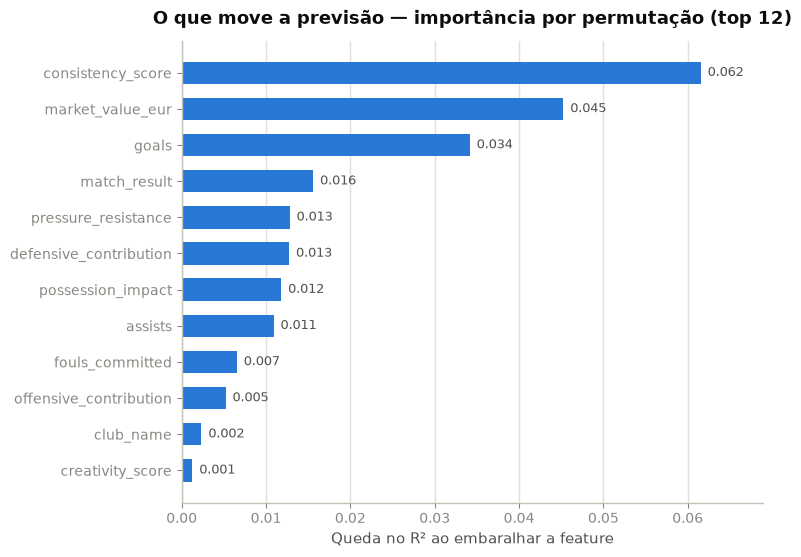

In [11]:
perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

importancias = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=True)
top = importancias.tail(12)

fig, ax = plt.subplots(figsize=(7.5, 6))

ax.barh(top.index, top.values, color=AZUL, height=0.62)
for i, v in enumerate(top.values):
    ax.annotate(f"{v:.3f}", xy=(v, i), xytext=(5, 0), textcoords="offset points",
                va="center", color=TINTA_2, fontsize=9)

ax.margins(x=0.12)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Queda no R² ao embaralhar a feature")
ax.set_title("O que move a previsão — importância por permutação (top 12)")

salvar(fig, "03_importancia_features.png")
plt.show()

A leitura do ranking é o insight do projeto:

- **`consistency_score` é a feature mais importante**, seguida de **`market_value_eur`** — os dois
  são atributos *do jogador*, não da partida. O gerador do dataset aparentemente deu a jogadores
  "melhores" (mais caros, mais consistentes) notas maiores em média.
- **`goals` é a estatística de partida mais importante** — a mais intuitiva possível: gol muda a
  nota. `match_result` e `assists` vêm logo atrás, no mesmo espírito.
- **`club_name` contribui pouco, mas contribui** — coerente com o sinal fraco que medimos no
  `02_feature_engineering`. A decisão do target encoding se pagou: uma coluna compacta, sem
  vazamento, com ganho real (ainda que pequeno).
- A grande maioria das ~60 features restantes tem importância ≈ 0 — típico de dado sintético:
  muitas colunas existem, poucas participaram da fórmula da nota.

## 11. Conclusões

O que este notebook estabeleceu:

| Pergunta | Resposta |
|---|---|
| Dá para prever o rating a partir das estatísticas legítimas? | Sim, parcialmente: MAE ~0.49 (16% melhor que o baseline), R² ~0.29 |
| O modelo generaliza? | Sim — treino e teste quase empatados, sem overfitting relevante |
| O que move a nota? | Qualidade do jogador (`consistency_score`, `market_value_eur`) + impacto na partida (`goals`, `match_result`, `assists`) |
| O rating é "explicável"? | Só ~29% — o resto é ruído do gerador sintético, que nenhuma feature legítima alcança |

O contraste que resume o projeto: com as colunas vazadas, teríamos R² ~0.99 e um insight falso;
sem elas, R² ~0.29 e um insight verdadeiro. **Um modelo honesto sobre dados ruidosos vale mais do
que um modelo perfeito sobre uma pergunta viciada.**

**Possíveis próximos passos:** tuning de hiperparâmetros (grid/random search com validação
cruzada), comparar com outros algoritmos (regressão linear como referência simples, XGBoost),
ou trocar a formulação — por exemplo, classificar o desbalanceado `player_of_match_awards`, que
traria os desafios de classe rara mapeados no `01_eda`.